# Chapter 6 — Use Cases

## Operational demonstrations of the tb-scouting framework

This notebook illustrates how the framework introduced in the previous chapters can be operationalised on real scouting questions. Five representative use cases are presented, each combining the role-matching engine (`src.matching`) with the visualisation layer (`src.visualisation`):

1. **Finding ball-playing centre-backs** — talent identification for a possession-based system.
2. **Finding pressing forwards** — talent identification for a high-press style.
3. **Player profiling** — characterising the natural role of Luka Modrić.
4. **Similarity search** — retrieving the closest stylistic neighbours of Marco Verratti.
5. **Custom role search** — defining a bespoke tactical profile that is not in the predefined catalogue. *This is the original methodological contribution of the framework: rather than constraining the analyst to a fixed set of templates, the scoring engine accepts any weighted combination of metrics, expressed directly in Python.*

All metrics are derived from StatsBomb open event data for the 2015/16 season of the five major European leagues (La Liga, Premier League, Bundesliga, Ligue 1, Serie A). Players are filtered at a minimum of 450 minutes played. All visualisations are exported as PNG (300 DPI) to the project's `results/` directory (resolved relative to the project root, independent of the working machine).

## Setup

In [1]:
import sys
from pathlib import Path

# Resolve the project root relative to this notebook so that the code runs
# unchanged on any machine (Windows, macOS, Linux) and any clone location.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from src.matching import (
    rank_players_by_role,
    find_similar_players,
    profile_player,
    custom_role_search,
    list_available_metrics,
)
from src.visualisation import (
    plot_radar_chart,
    plot_ranking_table,
    plot_pca_scatter,
    plot_player_card,
    plot_custom_radar,
)

RESULTS_DIR = PROJECT_ROOT / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

# Display options for clean tabular output
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 140)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

print(f'Project root     : {PROJECT_ROOT}')
print(f'Results directory: {RESULTS_DIR}')

Project root     : C:\tb-scouting
Results directory: C:\tb-scouting\results


---

## Use case 1 — Finding ball-playing centre-backs

**Scouting brief.** A coach setting up a possession-based 4-3-3 with a build-up out of the back requires a centre-back who is comfortable in tight spaces, distributes accurately under pressure, and contributes to ball progression rather than merely clearing the lines. The tactical literature labels this profile a *Ball-Playing Defender* (BPD), defined in our role taxonomy by high weights on progressive passing, completion rate, progressive carries, passes into the final third, and ball-progression metrics — while still retaining baseline defensive solidity.

**Method.** We score every centre-back (`position_group = 'CB'`, minutes ≥ 450) against the `ball_playing_defender` profile from `config/role_profiles.yaml`. The score is a weighted cosine similarity between the player's MinMax-normalised metric vector and the 90th-percentile reference vector of the CB population — bounded in [0, 100]. The ranking table is rendered as a calibrated visual, and the top-ranked candidate is then drilled into via a radar chart that contrasts his per-90 profile with the ideal.

In [2]:
# Score every CB against the ball-playing-defender profile
uc1_ranking = rank_players_by_role(
    role_name='ball_playing_defender',
    position='CB',
    min_minutes=450,
    top=10,
    verbose=False,
)
uc1_ranking.head(10)

,player_name,team,minutes_total,score,cluster,role_label
0,Javier Alejandro Mascherano,Barcelona,2718.55,92.01,1,CB-1
1,Marc Bartra Aregall,Barcelona,504.47,90.75,1,CB-1
2,Thiago Emiliano da Silva,Paris Saint-Germain,2661.47,89.22,1,CB-1
3,Andreu Fontàs Prat,Celta Vigo,552.48,88.41,1,CB-1
4,Joshua Kimmich,Bayern Munich,1411.17,87.14,1,CB-1
5,Gerard Piqué Bernabéu,Barcelona,2599.08,86.56,1,CB-1
6,Sergio Ramos García,Real Madrid,1951.18,85.74,1,CB-1
7,Marcos Aoás Corrêa,Paris Saint-Germain,1864.02,85.44,1,CB-1
8,David Luiz Moreira Marinho,Paris Saint-Germain,2109.98,84.96,1,CB-1
9,Ronaldo Aparecido Rodrigues,Wolfsburg,2602.30,84.44,1,CB-1


[saved] C:\tb-scouting\results\uc1_ranking_bpd.png


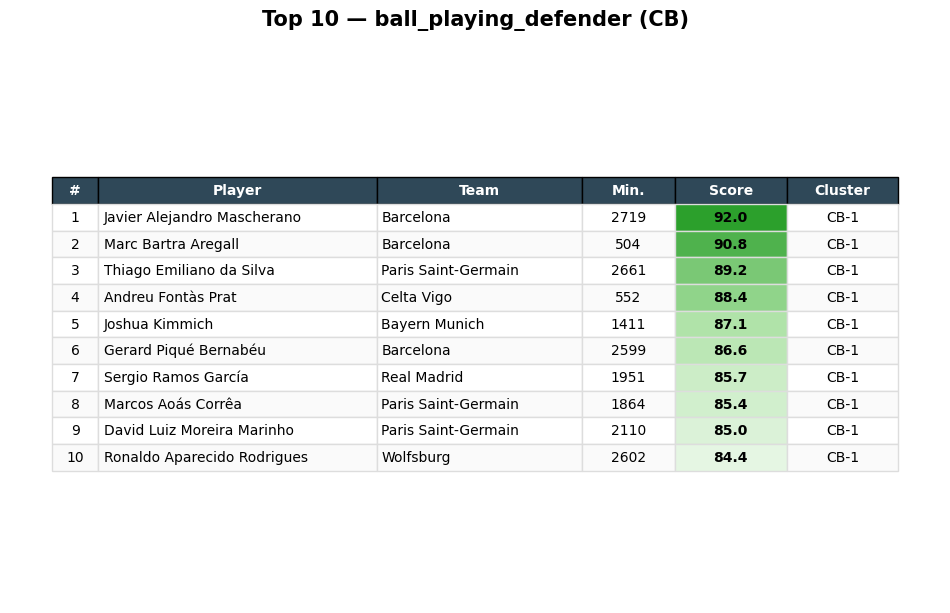

In [3]:
# Visualise the top 10 as a ranking table
fig = plot_ranking_table(
    role_name='ball_playing_defender',
    position='CB',
    top_n=10,
    save_path='uc1_ranking_bpd.png',
)
plt.show()

Top-ranked ball-playing defender: Javier Alejandro Mascherano


[saved] C:\tb-scouting\results\uc1_radar_bpd_top1.png


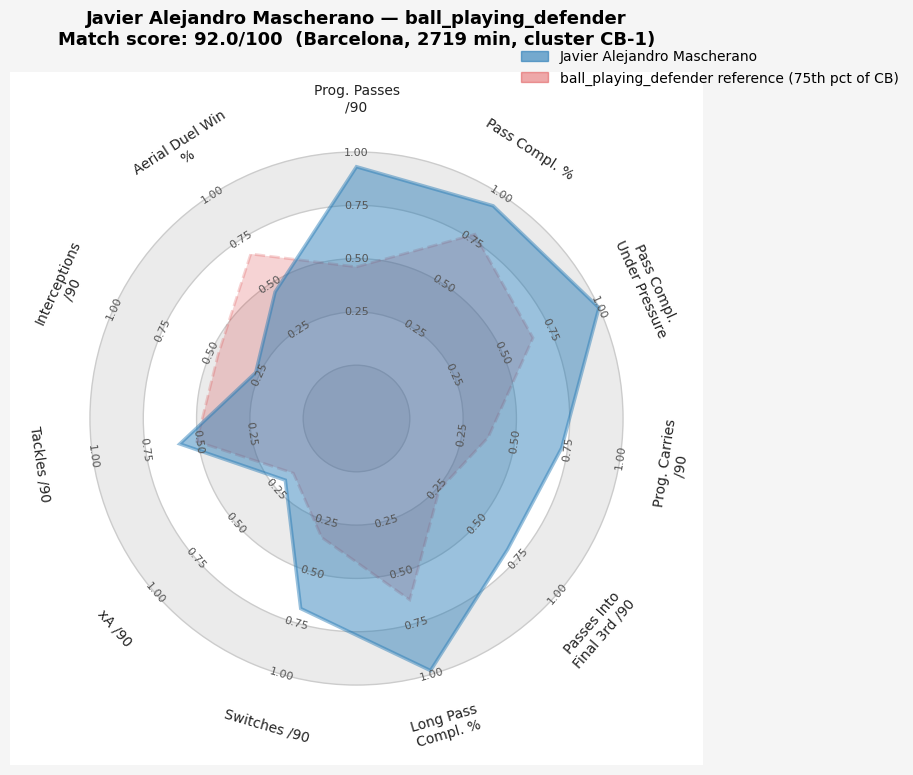

In [4]:
# Drill into the #1 candidate with a radar chart against the ideal profile
top1_name = uc1_ranking.iloc[0]['player_name']
print(f'Top-ranked ball-playing defender: {top1_name}')

fig = plot_radar_chart(
    player_name=top1_name,
    role_name='ball_playing_defender',
    position='CB',
    save_path='uc1_radar_bpd_top1.png',
)
plt.show()

**Reading.** The top of the ranking should populate with centre-backs known for elite progressive distribution — typically La Liga and Bundesliga profiles whose teams play from the back. The radar reveals *where* the candidate matches the BPD template (large overlapping blue and red regions on passing and progression axes) versus *where* he merely meets baseline expectations (defensive duel and aerial axes). The strengths/weaknesses lines in the ranking output further indicate, for each player, the specific metrics on which he over- or under-shoots the 90th-percentile reference — providing the analyst with an interpretable explanation rather than an opaque score.

---

## Use case 2 — Finding pressing forwards

**Scouting brief.** A high-pressing 4-3-3 (Klopp/Nagelsmann-style) hinges on a centre-forward willing to lead the first pressure on the opposition build-up. The *Pressing Forward* archetype combines a very high pressure volume, a strong pressure success rate (i.e., pressures that actually trigger a recovery within five seconds), recovery actions, and a baseline finishing ability — finishing is secondary to defensive workload from the front.

**Method.** Identical pipeline as use case 1, applied to the `pressing_forward` profile over the striker population (`position_group = 'ST'`, minutes ≥ 450). The role weights emphasise `pressures_p90`, `pressure_success_rate`, `recoveries_p90`, `tackles_p90` and `fouls_won_p90` — with reduced weight on shooting volume. This is a deliberately *defensive* striker profile, distinct from `advanced_forward` or `poacher`.

In [5]:
# Score every ST against the pressing-forward profile
uc2_ranking = rank_players_by_role(
    role_name='pressing_forward',
    position='ST',
    min_minutes=450,
    top=10,
    verbose=False,
)
uc2_ranking.head(10)

,player_name,team,minutes_total,score,cluster,role_label
0,Ángel Martín Correa,Atlético Madrid,951.58,89.64,1,ST-1
1,José Leonardo Ulloa,Leicester City,1030.50,85.23,3,ST-3
2,Dario Lezcano,Ingolstadt,1248.38,79.77,3,ST-3
3,Yassine Benzia,Lille,1343.78,78.83,3,ST-3
4,Alexander Baumjohann,Hertha Berlin,463.45,77.53,1,ST-1
5,Paulo Bruno Exequiel Dybala,Juventus,2482.25,77.35,1,ST-1
6,Billy Ketkeophomphone,Angers,2711.57,76.14,3,ST-3
7,Lars Edi Stindl,Borussia Mönchengladbach,2598.95,75.94,1,ST-1
8,M''Baye Babacar Niang,AC Milan,1146.22,75.44,3,ST-3
9,Martin Harnik,VfB Stuttgart,1005.15,75.43,3,ST-3


[saved] C:\tb-scouting\results\uc2_ranking_pressing_forward.png


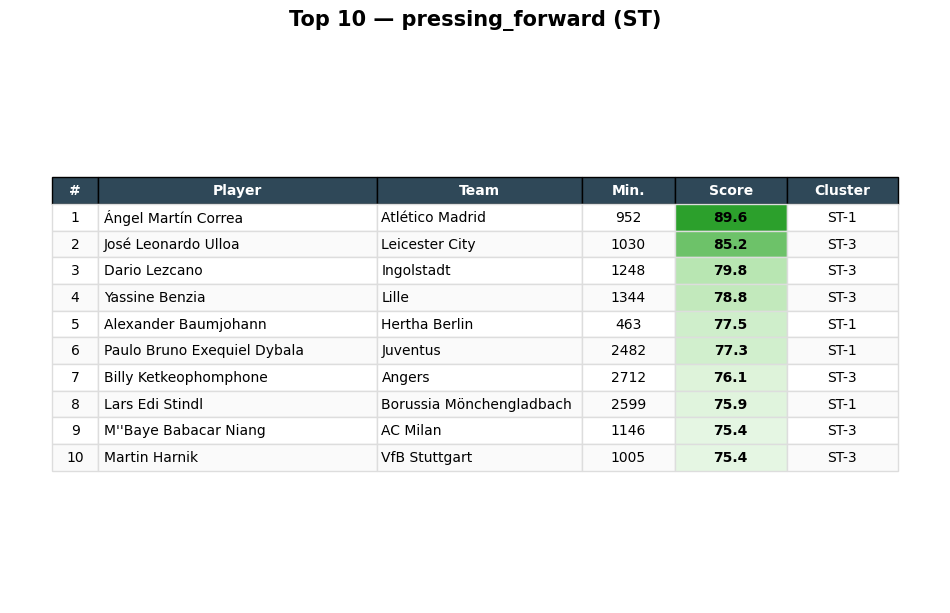

In [6]:
# Visualise the top 10 as a ranking table
fig = plot_ranking_table(
    role_name='pressing_forward',
    position='ST',
    top_n=10,
    save_path='uc2_ranking_pressing_forward.png',
)
plt.show()

Top-ranked pressing forward: Ángel Martín Correa


[saved] C:\tb-scouting\results\uc2_radar_pressing_forward_top1.png


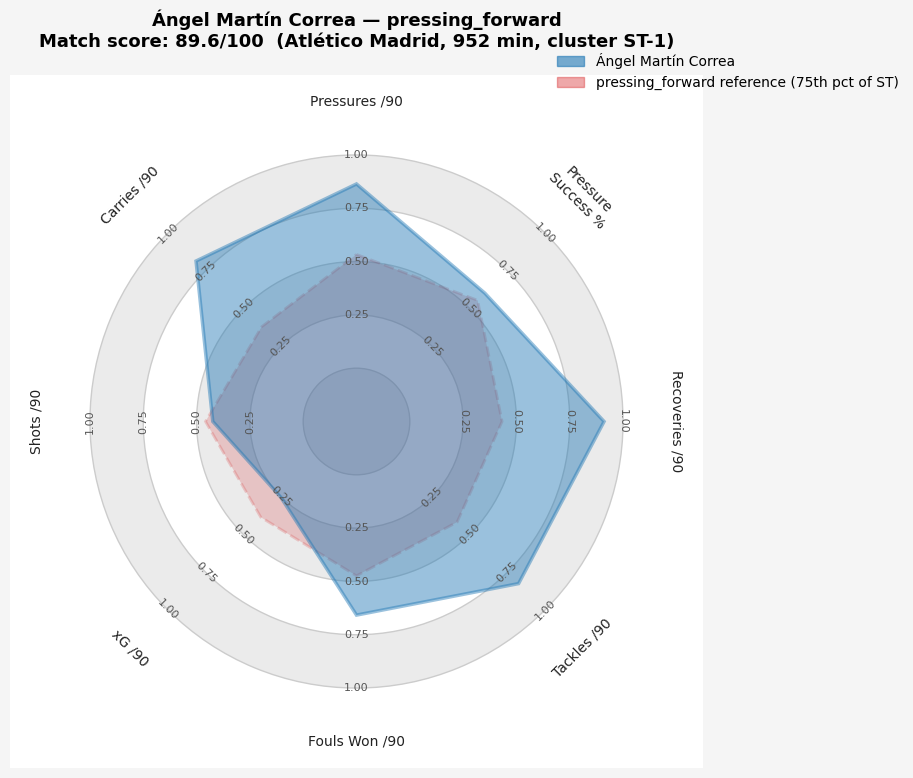

In [7]:
# Drill into the #1 candidate
top1_name = uc2_ranking.iloc[0]['player_name']
print(f'Top-ranked pressing forward: {top1_name}')

fig = plot_radar_chart(
    player_name=top1_name,
    role_name='pressing_forward',
    position='ST',
    save_path='uc2_radar_pressing_forward_top1.png',
)
plt.show()

**Reading.** The pressing-forward shortlist is expected to feature high-energy strikers from intensive-pressing teams — typically Bundesliga and Premier League forwards rather than finishers in possession-dominant sides. The radar chart highlights the defining duality of the role: an elite ceiling on the pressing and recovery axes, contrasted with intentionally moderate offensive output. Strikers who score highly here despite lower xG numbers should not be discounted — they would be a poor fit for the `poacher` role but a strong fit for the tactical brief at hand. This use case illustrates the value of role-conditioned scoring over a single global rating: the same player can be "weak" or "strong" depending on which template he is evaluated against.

---

## Use case 3 — Player profiling: what is Modrić's natural role?

**Analytical brief.** The previous use cases project the search direction *from a role onto a population*. Profiling reverses the direction: given a known player, *which of the predefined tactical roles does his statistical signature most closely match?* This is a diagnostic application — useful for tactical scouting reports, for evaluating whether a recruiting target would fit an existing role in the squad, or for confirming whether a player's empirical output aligns with the role he is nominally deployed in.

**Method.** For each role defined in `role_profiles.yaml` under the player's `position_group`, the same weighted cosine similarity is computed. The role with the highest score is declared the *natural role* — empirically the one his per-90 profile most closely resembles. The full ranking is also reported, since the second- and third-best roles are themselves informative about tactical flexibility. The player card visualises this together with strengths, weaknesses, and the closest stylistic neighbours.

In [8]:
# Full role profile of Modrić across all MF role templates
uc3_profile = profile_player('Modric', position='MF', verbose=True)
uc3_profile


=== Profile of "Luka Modrić" (Real Madrid, MF, 2634 min) ===
  deep_lying_playmaker           89.86  <-- natural role
  mezzala                        83.54
  box_to_box_midfielder          66.43
  ball_winning_midfielder        50.22


,role_name,score,is_natural
0,deep_lying_playmaker,89.86,True
1,mezzala,83.54,False
2,box_to_box_midfielder,66.43,False
3,ball_winning_midfielder,50.22,False


Modric's natural role: deep_lying_playmaker


[saved] C:\tb-scouting\results\uc3_card_modric_natural.png


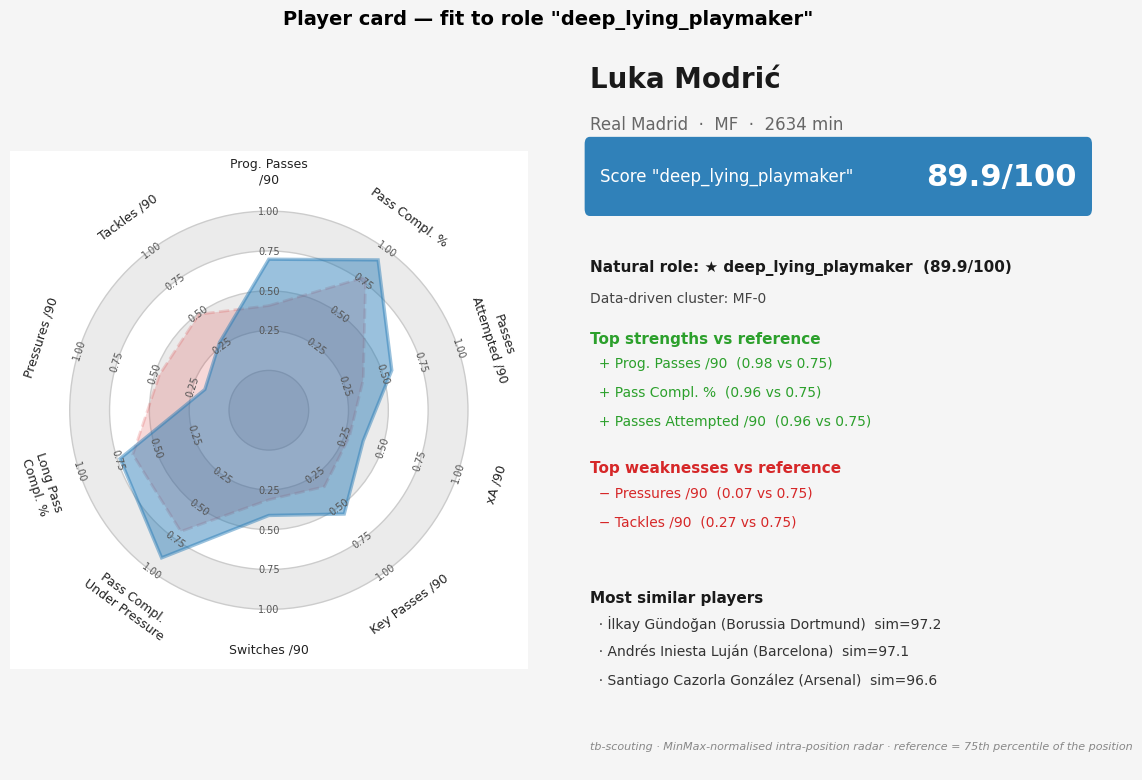

In [9]:
# Render the full player card against his natural (top-ranked) role
natural_role = uc3_profile.iloc[0]['role_name']
print(f"Modric's natural role: {natural_role}")

fig = plot_player_card(
    player_name='Modric',
    role_name=natural_role,
    position='MF',
    save_path='uc3_card_modric_natural.png',
)
plt.show()

**Reading.** Modrić's role profile distribution is itself the analytical artefact: a player whose top score is markedly higher than the rest is a *role-specialist*, whereas a player with several near-tied scores is *positionally versatile*. The player card consolidates all the diagnostic information in a single A4-landscape artefact suitable for inclusion in scouting dossiers: the radar visualises the alignment with the inferred natural role, while the right-hand panel surfaces the empirical evidence (cluster membership, top strengths, top weaknesses, and the three closest stylistic neighbours). The cluster label (data-driven, unsupervised) and the natural role (theory-driven, role-template-based) provide two independent perspectives that the analyst can triangulate.

---

## Use case 4 — Finding players similar to Verratti

**Scouting brief.** A frequent operational question in recruitment is the *replacement search*: identify players whose statistical signature most resembles a reference player. In this case the reference is Marco Verratti, a high-volume, press-resistant deep-lying midfielder. The objective is to surface alternative candidates with a comparable on-ball profile across the five major European leagues.

**Method.** Unlike the role-based scoring of use cases 1 and 2, similarity search uses the *full* metric vector of the reference player as the query. Each candidate's vector — MinMax-normalised within the same `position_group` — is compared via cosine similarity. The result is a role-agnostic ranking driven entirely by the data, with no tactical template imposed. The PCA scatter plot then localises Verratti within the two-dimensional projection of the MF population, with cluster membership colour-coded, allowing the analyst to see which region of the role-space the similar players inhabit.

In [10]:
# Top 10 players most similar to Verratti
uc4_similar = find_similar_players('Verratti', position='MF', top_n=10)
uc4_similar

,player_name,team,position_group,minutes_total,similarity,role_label
0,Jorge Luiz Frello Filho,Napoli,MF,2962.92,95.49,MF-0
1,Jean Michaël Seri,OGC Nice,MF,3145.02,92.56,MF-0
2,Xabier Alonso Olano,Bayern Munich,MF,1939.23,92.25,MF-0
3,Julian Weigl,Borussia Dortmund,MF,2247.83,91.98,MF-0
4,Jordan Ferri,Lyon,MF,2468.85,91.81,MF-0
5,Francesc Fàbregas i Soler,Chelsea,MF,2999.40,91.63,MF-0
6,İlkay Gündoğan,Borussia Dortmund,MF,1998.08,91.49,MF-0
7,Luka Modrić,Real Madrid,MF,2633.52,91.34,MF-0
8,João Filipe Iria Santos Moutinho,AS Monaco,MF,2174.57,91.32,MF-0
9,Borja Valero Iglesias,Fiorentina,MF,3163.53,91.28,MF-0


[saved] C:\tb-scouting\results\uc4_pca_verratti.png


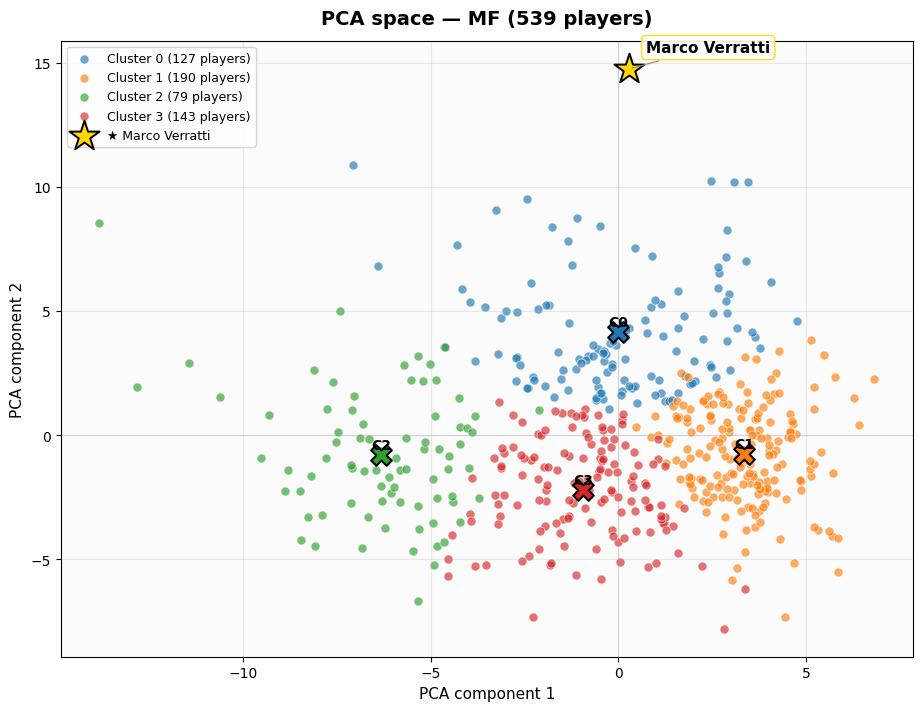

In [11]:
# Locate Verratti and his stylistic neighbours in PCA space
fig = plot_pca_scatter(
    position='MF',
    highlight_player='Verratti',
    save_path='uc4_pca_verratti.png',
)
plt.show()

**Reading.** The similarity ranking surfaces an analytically meaningful neighbourhood: the most similar players should belong predominantly to the same data-driven cluster as Verratti, validating the consistency of the framework. The PCA scatter confirms this visually — the gold star (Verratti) sits inside the cluster region populated by his nearest stylistic neighbours, distant from the centroids of the other clusters that capture more defensive or more advanced midfielder profiles. The combination of the ranked similarity table and the spatial visualisation provides both a deterministic shortlist ("these ten players are the closest matches") and a topological understanding ("this is the region of role-space he occupies").

---

## Use case 5 — Custom role search: defining your own tactical profile

**Scouting brief.** A coach is preparing for a Champions League knockout tie in which the opposition delivers a high volume of crosses and set pieces. He needs a centre-back who can build out from the back *and* dominate aerially in his own box — a combination that the predefined `ball_playing_defender` role under-weights (its `aerial_duel_win_rate` weight is only 0.5) and that `no_nonsense_cb` over-corrects on (it explicitly demotes passing). No single template in `config/role_profiles.yaml` fits the brief.

**Method.** Rather than editing the YAML or fitting the search to an imperfect template, the analyst defines a *custom role profile* directly in code as a Python dict of metric weights. The same weighted-percentile scoring engine that powers the predefined roles consumes the dict transparently — no other change is needed in the pipeline. This is the framework's most flexible entry point and, methodologically, its main original contribution: tactical roles become **first-class objects expressible at the call site**, not configuration items locked in a YAML file.

The helper `list_available_metrics(position)` is provided to discover the exact metric names the dataset offers for any given position group.

In [12]:
# Discover the metric vocabulary for centre-backs
available = list_available_metrics('CB')
for category, metrics in available.items():
    print(f'[{category}] ({len(metrics)})')
    for m in metrics:
        print(f'   - {m}')

[passing] (13)
   - crosses_p90
   - key_passes_p90
   - long_passes_completed_p90
   - long_passes_p90
   - passes_attempted_p90
   - passes_completed_p90
   - passes_completed_under_pressure_p90
   - passes_into_final_third_p90
   - passes_into_penalty_area_p90
   - passes_under_pressure_p90
   - progressive_passes_p90
   - switches_p90
   - xA_p90
[defending] (10)
   - aerial_duels_p90
   - aerial_duels_won_p90
   - blocks_p90
   - clearances_p90
   - defensive_actions_p90
   - ground_duels_p90
   - ground_duels_won_p90
   - interceptions_p90
   - recoveries_p90
   - tackles_p90
[progression] (5)
   - carries_into_final_third_p90
   - carries_into_penalty_area_p90
   - carries_p90
   - carry_distance_p90
   - progressive_carries_p90
[pressing] (2)
   - pressures_p90
   - pressures_successful_p90
[attacking] (7)
   - dribbles_attempted_p90
   - dribbles_completed_p90
   - shots_first_touch_p90
   - shots_on_target_p90
   - shots_p90
   - touches_in_box_p90
   - xG_p90
[general] (5)
 

Below, the brief is encoded as seven weighted metrics. The build-up dimension is captured by `pass_completion_rate`, `pass_completion_under_pressure`, `progressive_passes_p90` and `progressive_carries_p90`. The aerial dimension — the explicit upgrade over the standard `ball_playing_defender` role — is encoded with both `aerial_duel_win_rate` (efficiency) and `aerial_duels_p90` (volume). A light `tackles_p90` weight retains a baseline of ground defending without dominating the score.

In [13]:
# Define the custom tactical profile — "aerial-dominant ball-playing CB"
custom_weights = {
    'pass_completion_rate':           3.0,
    'pass_completion_under_pressure': 2.5,
    'progressive_passes_p90':         2.0,
    'progressive_carries_p90':        2.0,
    'aerial_duel_win_rate':           3.0,   # heavier than standard BPD (0.5)
    'aerial_duels_p90':               2.5,   # not present in standard BPD
    'tackles_p90':                    1.0,
}

uc5_custom = custom_role_search(
    position='CB',
    custom_weights=custom_weights,
    min_minutes=450,
    top=10,
    verbose=False,
)
uc5_custom.head(10)[['player_name', 'team', 'minutes_total', 'score',
                     'cluster', 'role_label']]

,player_name,team,minutes_total,score,cluster,role_label
0,Mats Hummels,Borussia Dortmund,2505.33,86.00,1,CB-1
1,Holger Badstuber,Bayern Munich,467.77,85.88,1,CB-1
2,Medhi Amine El Mouttaqi Benatia,Bayern Munich,976.65,85.04,1,CB-1
3,Ronaldo Aparecido Rodrigues,Wolfsburg,2602.30,84.08,1,CB-1
4,Thiago Emiliano da Silva,Paris Saint-Germain,2661.47,83.73,1,CB-1
5,Javier Martínez Aginaga,Bayern Munich,1107.38,83.44,1,CB-1
6,Sokratis Papastathopoulos,Borussia Dortmund,2113.45,81.71,1,CB-1
7,Mamadou Sakho,Liverpool,1901.65,80.16,2,CB-2
8,Gerard Piqué Bernabéu,Barcelona,2599.08,79.78,1,CB-1
9,Loïc Perrin,Saint-Étienne,2130.65,79.53,2,CB-2


In [14]:
# Compare with the standard ball_playing_defender ranking
uc5_bpd = rank_players_by_role('ball_playing_defender', 'CB',
                                top=10, verbose=False)

bpd_top = set(uc5_bpd.head(10)['player_name'])
cus_top = set(uc5_custom.head(10)['player_name'])

print(f'Common to both top-10s : {len(bpd_top & cus_top)} player(s)')
print(f'Only in BPD top-10     : {len(bpd_top - cus_top)} player(s)')
print(f'Only in custom top-10  : {len(cus_top - bpd_top)} player(s)')

print('\nDropped (BPD only — strong passer, weak aerial):')
for n in sorted(bpd_top - cus_top):
    print(f'  - {n}')

print('\nAdded (custom only — strong passer AND strong aerial):')
for n in sorted(cus_top - bpd_top):
    print(f'  - {n}')

Common to both top-10s : 3 player(s)
Only in BPD top-10     : 7 player(s)
Only in custom top-10  : 7 player(s)

Dropped (BPD only — strong passer, weak aerial):
  - Andreu Fontàs Prat
  - David Luiz Moreira Marinho
  - Javier Alejandro Mascherano
  - Joshua Kimmich
  - Marc Bartra Aregall
  - Marcos Aoás Corrêa
  - Sergio Ramos García

Added (custom only — strong passer AND strong aerial):
  - Holger Badstuber
  - Javier Martínez Aginaga
  - Loïc Perrin
  - Mamadou Sakho
  - Mats Hummels
  - Medhi Amine El Mouttaqi Benatia
  - Sokratis Papastathopoulos


Top-ranked under the custom profile: Mats Hummels


[saved] C:\tb-scouting\results\uc5_custom_radar_top1.png


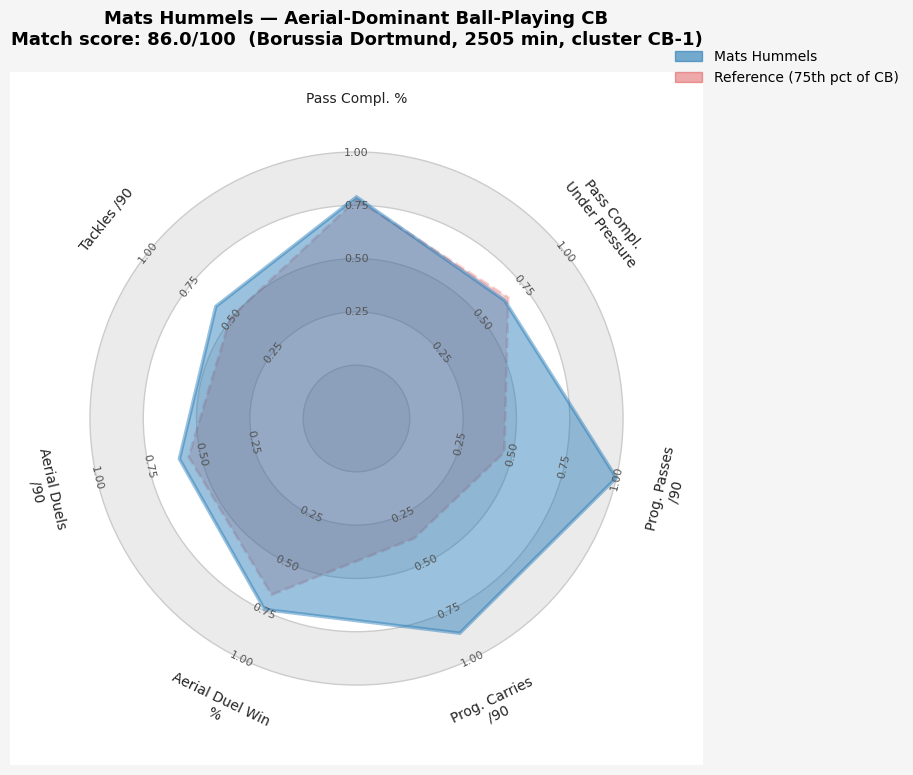

In [15]:
# Visualise the #1 custom-ranked centre-back against the 75th-percentile reference
top1_name = uc5_custom.iloc[0]['player_name']
print(f'Top-ranked under the custom profile: {top1_name}')

fig = plot_custom_radar(
    player_name=top1_name,
    custom_weights=custom_weights,
    position='CB',
    save_path='uc5_custom_radar_top1.png',
    profile_label='Aerial-Dominant Ball-Playing CB',
)
plt.show()

**Reading.** The custom ranking diverges from the standard `ball_playing_defender` top-10 in a way that is *empirically explained by the brief itself*. Two cohorts of players move:

- **Players dropped from the BPD ranking when aerial weights are added.** These are technically gifted but physically smaller centre-backs — typically La Liga distributors built for tight-space possession football rather than aerial battles. They remain elite passers but no longer dominate a profile that demands aerial output.

- **Players added by the custom profile.** These are large, technically capable centre-backs who combine credible distribution with proper aerial dominance — the archetypal profile a coach wants when preparing for an opponent that lives off crosses and set pieces. They were *hidden* in the standard BPD ranking because the role's aerial weight (0.5) was too low to surface them above the smaller, purer passers.

This use case illustrates the methodological value of opening the role definition to the analyst. A predefined role catalogue inevitably reflects the catalogue author's tactical assumptions; in a domain as plastic as football, no catalogue can anticipate every brief. The custom-role mechanism converts the YAML from a *constraint* into a *starting library* that the analyst can extend, override, or bypass entirely with three lines of Python — a property that, to the author's knowledge, no comparable open-source scouting framework currently exposes.

---

## Closing remarks

The five use cases above demonstrate the operational utility of a unified pipeline that fuses (i) low-level event aggregation from StatsBomb, (ii) position-conditioned normalisation and unsupervised clustering, (iii) theory-driven role templates encoded in a YAML configuration, (iv) a custom-role mechanism that lets the analyst express bespoke tactical briefs directly as Python dictionaries, and (v) visualisations suitable for inclusion in scouting reports.

The atomic functions — `rank_players_by_role`, `find_similar_players`, `profile_player`, `custom_role_search`, and their visual counterparts — can be recomposed to address any scouting brief that can be framed as *find players matching a template*, *find players resembling a reference*, or *find players matching an arbitrary weighted profile*. Adding a new tactical role amounts to declaring its metric weights in the YAML; testing an ad-hoc profile requires no configuration change at all; adding a new metric amounts to extending the feature-engineering stage in `src/features.py`. The framework is therefore extensible without requiring any change to the matching or visualisation logic — the principle of separation of concerns that underpins the design choices documented in chapters 3 to 5.